## Loading and visualizing data from flat files (using AI)
## Part 1

In [1]:
import pandas as pd


In [2]:
# Read without headers
df = pd.read_csv('for_nitpicker.dat', sep='\t',header=None,
                names=['Date', 'Time', 'Depth', 'Temperature', 'Salinity']
                )
# Overwrite with header
df.to_csv('CTD_DATA1.csv',index=False)
df.head()

,Date,Time,Depth,Temperature,Salinity
0,11/29/2008,06:52,5,28.97,35.21
1,11/29/2008,06:52,6,28.98,35.21
2,11/29/2008,06:52,7,28.99,35.21
3,11/29/2008,06:52,8,28.96,35.21
4,11/29/2008,06:52,9,28.99,35.21


## Part 2

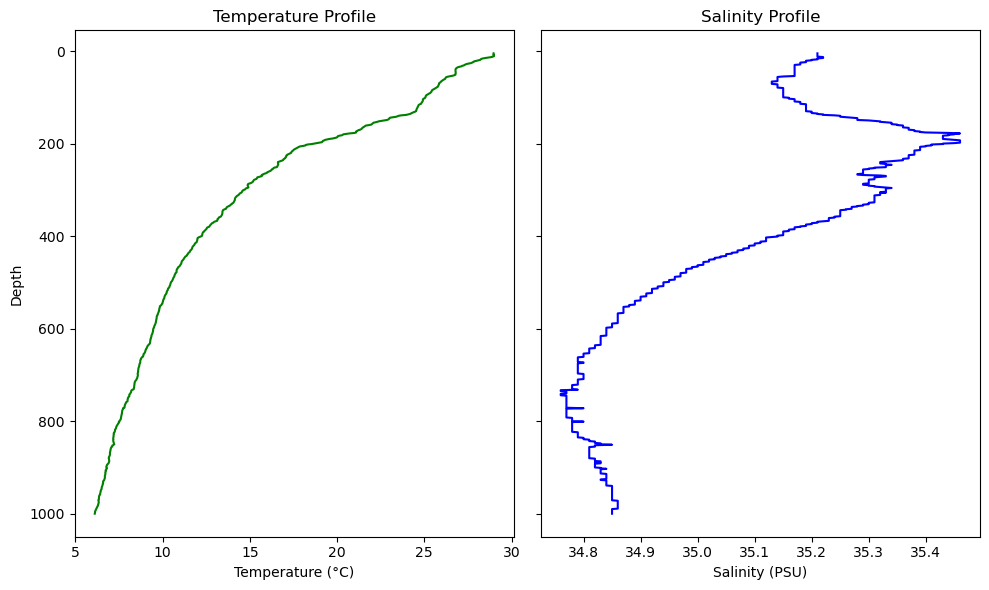

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
df = pd.read_csv("CTD_DATA1.csv")
y= df["Depth"]
temp = df["Temperature"]
sal = df["Salinity"]
fig, axes = plt.subplots(ncols=2, sharey=True, figsize=(10, 6))

# Temperature profile
axes[0].plot(temp, y, color= "green")
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Depth")
axes[0].set_title("Temperature Profile")
# Salinity profile
axes[1].plot(sal, y, color="blue")
axes[1].set_xlabel("Salinity (PSU)")
axes[1].set_title("Salinity Profile")

axes[0].invert_yaxis()
# Invert y-axis (important for ocean depth!)
plt.tight_layout()
plt.show()

## PART 3

In [4]:
import pandas as pd
import numpy as np


In [5]:
file_path = "SAA2_WC_2017_metocean_10min_avg.csv"

In [6]:
df = pd.read_csv(file_path, na_values=['NULL'])

# Convert TIME_SERVER to datetime and set as index
df['TIME_SERVER'] = pd.to_datetime(df['TIME_SERVER'], format='%Y/%m/%d %H:%M')
df.set_index('TIME_SERVER', inplace=True)

In [7]:
start_date = df.index.min()      
end_date = '2017-07-04'             
mask = (df.index >= start_date) & (df.index <= end_date)
df_selected = df.loc[mask].copy()

print(f"Data selected from {start_date.date()} to {end_date}")

Data selected from 2017-06-28 to 2017-07-04


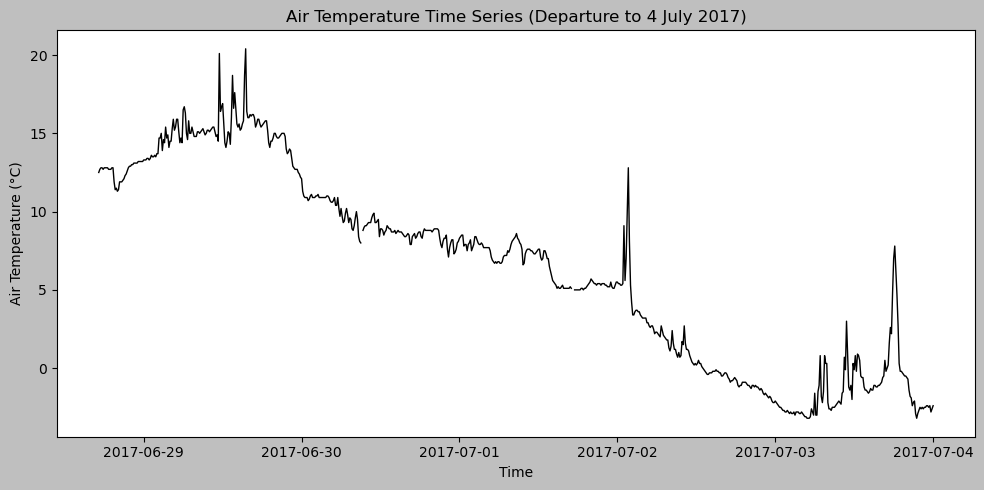

Temperature time series saved as 'temperature_timeseries.png'


In [8]:
plt.style.use('grayscale')
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_selected.index, df_selected['AIR_TEMPERATURE'], linewidth=1)
ax.set_xlabel('Time')
ax.set_ylabel('Air Temperature (°C)')
ax.set_title('Air Temperature Time Series (Departure to 4 July 2017)')
plt.tight_layout()
plt.savefig('temperature_timeseries.png', dpi=300)
plt.show()
print("Temperature time series saved as 'temperature_timeseries.png'")


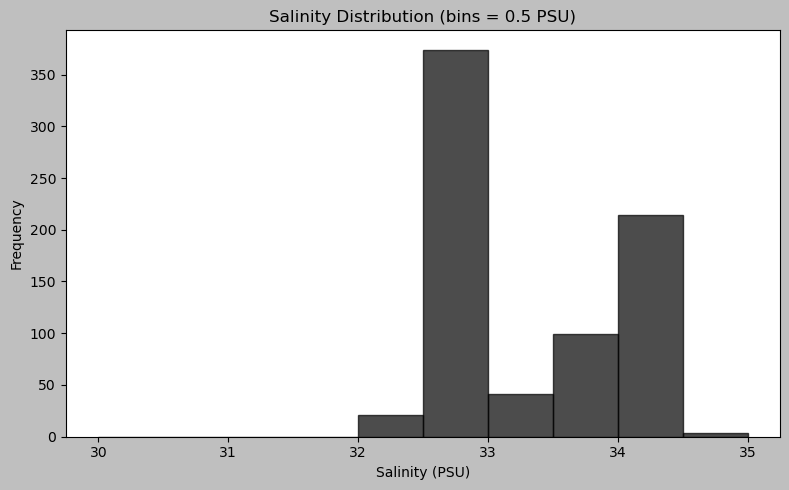

Salinity histogram saved as 'salinity_histogram.png'


In [9]:
salinity = df_selected['TSG_SALINITY'].dropna()
bins = np.arange(30, 35.5, 0.5)   # bins from 30 to 35 inclusive, step 0.5

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(salinity, bins=bins, edgecolor='black', alpha=0.7)
ax.set_xlabel('Salinity (PSU)')
ax.set_ylabel('Frequency')
ax.set_title('Salinity Distribution (bins = 0.5 PSU)')
plt.tight_layout()
plt.savefig('salinity_histogram.png', dpi=300)
plt.show()
print("Salinity histogram saved as 'salinity_histogram.png'")

In [10]:
temp = df_selected['AIR_TEMPERATURE'].dropna()
sal = df_selected['TSG_SALINITY'].dropna()

temp_mean = temp.mean()
temp_std = temp.std()
temp_iqr = temp.quantile(0.75) - temp.quantile(0.25)

sal_mean = sal.mean()
sal_std = sal.std()
sal_iqr = sal.quantile(0.75) - sal.quantile(0.25)

# Create a summary table
stats_table = pd.DataFrame({
    'Variable': ['Air Temperature (°C)', 'Salinity (PSU)'],
    'Mean': [temp_mean, sal_mean],
    'Std Dev': [temp_std, sal_std],
    'IQR': [temp_iqr, sal_iqr]
})
print("\nSummary Statistics Table:")
print(stats_table.to_string(index=False))


Summary Statistics Table:
            Variable     Mean  Std Dev     IQR
Air Temperature (°C)  6.46614 6.098960 10.8500
      Salinity (PSU) 33.35233 0.737574  1.4742


In [11]:
def ddmm2dd(ddmm):
    """Convert DDMM.cccc to decimal degrees."""
    deg = np.floor(ddmm / 100.)
    minutes = (ddmm - deg * 100.) / 60.
    return deg + minutes

In [12]:
df_selected['LAT_DEC'] = df_selected['LATITUDE'].apply(ddmm2dd)
df_selected['LAT_DEC'] = np.where(df_selected['N_S'] == 'S', -df_selected['LAT_DEC'], df_selected['LAT_DEC'])

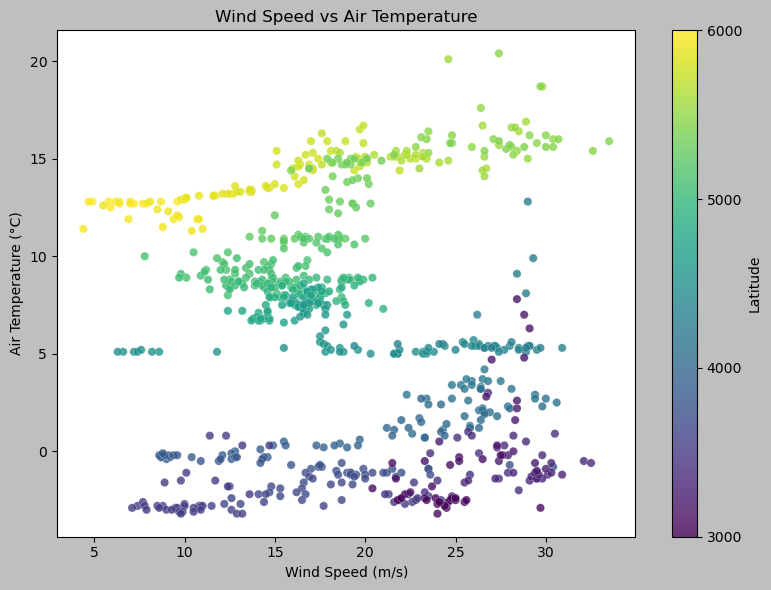

Scatter plot saved as 'wind_temp_scatter.png' (300 DPI)


In [13]:
scatter_data = df_selected[
    ['WIND_SPEED_TRUE', 'AIR_TEMPERATURE', 'LAT_DEC']
].dropna()
lat_original = scatter_data['LAT_DEC']

lat_scaled = 3000 + (
    (lat_original - lat_original.min())
    * (6000 - 3000)
    / (lat_original.max() - lat_original.min())
)
# scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    scatter_data['WIND_SPEED_TRUE'],
    scatter_data['AIR_TEMPERATURE'],
    
    # scaled latitude values
    c=lat_scaled,
    
    cmap='viridis',
    alpha=0.8,
    edgecolors='white',
    linewidth=0.2
)
# Labels
ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Air Temperature (°C)')
ax.set_title('Wind Speed vs Air Temperature')

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Latitude')

# cleaner ticks
cbar.set_ticks([3000, 4000, 5000, 6000])
# Layout
plt.tight_layout()
# Save figure
plt.savefig('wind_temp_scatter.png', dpi=300)
plt.show()
print("Scatter plot saved as 'wind_temp_scatter.png' (300 DPI)")
